## Overview

This notebook demonstrates how to build and evaluate a time series forecasting model using Facebook Prophet. Prophet is a modular forecasting tool developed by Meta that automatically captures trend, seasonality, and holidays components in time series data. It is widely used in both academia and industry due to its interpretability and ease of use.

The notebook walks through the complete workflow:

1. Data Preparation: Import and clean the Bitcoin price dataset, format the data into Prophet’s required structure with ds and y columns.

2.  Model Construction: Instantiate a Prophet model, optionally adding components such as yearly, weekly, or daily seasonality.

3. Model Training: Fit the model to historical Bitcoin price data.

4. Prediction: Use the trained model to forecast future prices or re-predict existing dates to evaluate model performance.

5. Visualization: Plot the forecast and its trend, seasonality, and uncertainty intervals to understand model behavior.

6. Evaluation: Compare predicted and actual values, and discuss model accuracy, potential biases, and limitations.

Through this notebook, students will learn:

1. How Prophet decomposes time series into interpretable components.

2. How to visualize and evaluate time series forecasts.

3. How to extend Prophet with additional regressors or holiday effects.

This exercise helps students gain hands-on experience with modern forecasting methods and understand their application in real-world data analysis.

## Install Packages and Load Libraries

In [1]:
# Uncomment the installation if you didn't install already
!pip install prophet==1.1.5 "numpy<2.0" cmdstanpy==1.2.0
!pip install matplotlib pandas plotly
!pip install pygam
!pip install holidays


In [2]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib.ticker import FuncFormatter
from statsmodels.gam.api import GLMGam, BSplines
from sklearn.preprocessing import MinMaxScaler
from statsmodels.nonparametric.smoothers_lowess import lowess
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation
from pygam import LinearGAM, s, f
from statsmodels.formula.api import ols

In [3]:
# disable warnings
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.basicConfig(level=logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)




In [4]:
# ========== evaluation methods ==========
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)



## Data Preprocessing

We load the Bitcoin dataset and print a preview of it. The Prophet model requires the dates to be datetime objects, and takes in a dataframe with two columns: ds (for the dates) and y, which is the target variable (bitcoin price in this case).

In [6]:
# ========== Load Data ==========
databtc = pd.read_csv('BTCUSD.csv')
# ========== Extract target variable and date ==========
pricebtc = databtc['Close']
mydates = pd.to_datetime(databtc['Date'])  # Adjust index if needed

# ========== Construct Prophet-ready DataFrame ==========
df = pd.DataFrame({'ds': mydates, 'y': pricebtc})

# ========== Filter date range: 2019-04-01 to 2025-04-01 ==========
start_date = pd.to_datetime('2019-04-01')
end_date = pd.to_datetime('2025-04-01')
df = df[(df['ds'] >= start_date) & (df['ds'] <= end_date)].sort_values('ds').reset_index(drop=True)

# ========== Check head and tail ==========
print("First 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

# ========== Split data into training and testing sets ==========
# Use all except the last 7 rows as training data
train_data = df.iloc[:-7].reset_index(drop=True)

# Use the last 7 rows as test data
test_data = df.iloc[-7:].reset_index(drop=True)

# ========== Print split information ==========
print(f"\nTraining data: {train_data.shape[0]} rows")
print(f"  Date range: {train_data['ds'].iloc[0]} to {train_data['ds'].iloc[-1]}")

print(f"\nTest data: {test_data.shape[0]} rows")
print(f"  Date range: {test_data['ds'].iloc[0]} to {test_data['ds'].iloc[-1]}")


First 5 rows:
          ds            y
0 2019-04-01  4158.183105
1 2019-04-02  4879.877930
2 2019-04-03  4973.021973
3 2019-04-04  4922.798828
4 2019-04-05  5036.681152

Last 5 rows:
             ds             y
2188 2025-03-28  84353.148438
2189 2025-03-29  82597.585938
2190 2025-03-30  82334.523438
2191 2025-03-31  82548.914062
2192 2025-04-01  85169.171875

Training data: 2186 rows
  Date range: 2019-04-01 00:00:00 to 2025-03-25 00:00:00

Test data: 7 rows
  Date range: 2025-03-26 00:00:00 to 2025-04-01 00:00:00


## Basic Prophet Model

Let's apply the basic Prophet model to the Bitcoin data.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/8juf5akg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/7kict13l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49760', 'data', 'file=/tmp/tmp5eduz8m0/8juf5akg.json', 'init=/tmp/tmp5eduz8m0/7kict13l.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_model3pjhoyc9/prophet_model-20251101200646.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:06:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:06:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


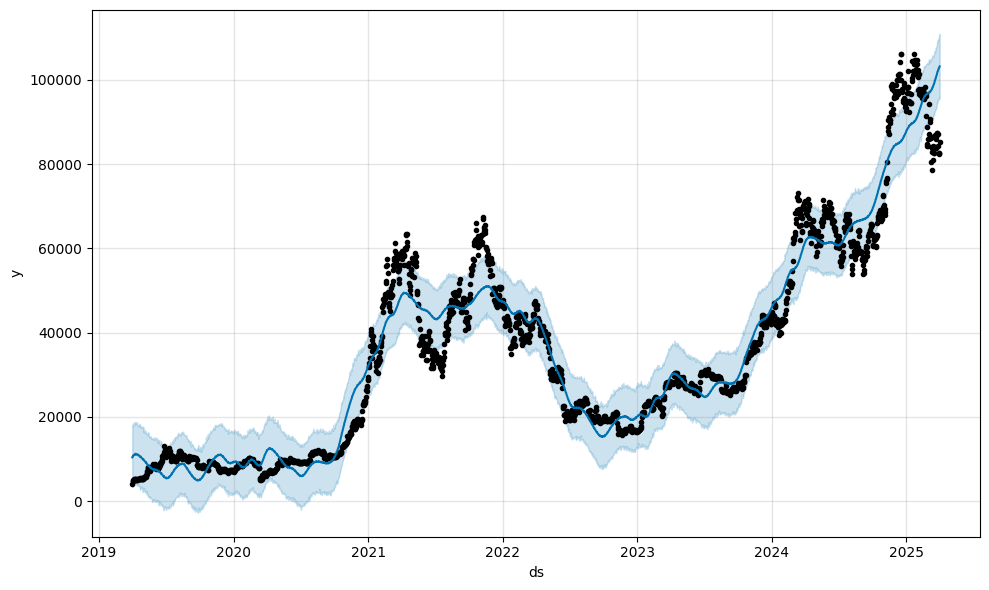

In [7]:
# fit basic prophet model and predict for existing dates
m = Prophet()
m.fit(df)
forecast = m.predict(df)
plot = m.plot(forecast)
plot.show()

As we can see in the plot above, the trend seems to fit the data quite well, if not too well!

Furthermore, we can compare this to the Local Polynomial and Splines Regression models we learned about in previous lessons.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/1fch8m2u.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/si8_ev8q.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86653', 'data', 'file=/tmp/tmp5eduz8m0/1fch8m2u.json', 'init=/tmp/tmp5eduz8m0/si8_ev8q.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelr47usza4/prophet_model-20251101200658.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:06:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:06:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


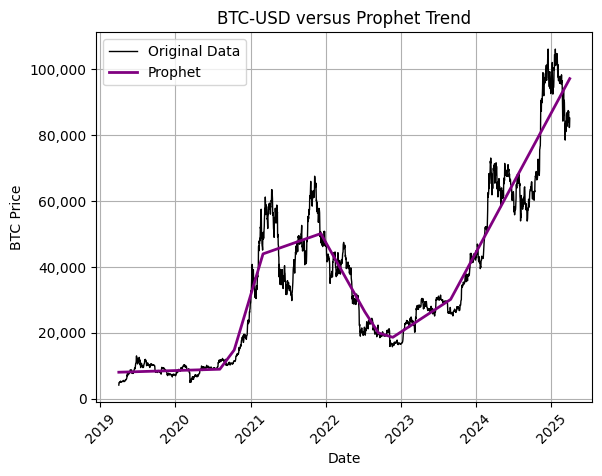

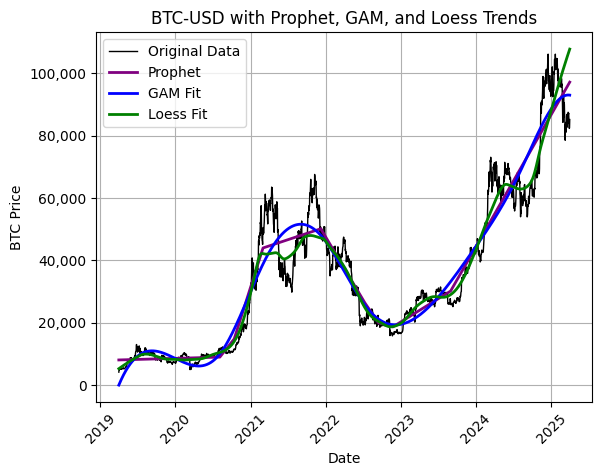

In [8]:
#Fit the Prophet model
#If we do not discard seasonality
m = Prophet()
# Discarding seasonality to capture trend only for comparison
m = Prophet(weekly_seasonality = False, yearly_seasonality = False)
m.fit(df)
forecast = m.predict(df)

# Convert forecast['ds'] to datetime format
forecast['ds'] = pd.to_datetime(forecast['ds'])

# Add GAM fit (note that this is a different implementation than gam() command in the mgcv library)
time_pts = np.arange(1, len(df) + 1)
bs = BSplines(time_pts[:, None], df=[12], degree=[3])
gam_model = GLMGam(df['y'], smoother=bs).fit()
df['gam_fit'] = gam_model.predict()

# Add Loess fit
loess_fit = lowess(df['y'], time_pts, frac=0.1)
df['loess_fit'] = loess_fit[:, 1]

# Plot Prophet trend only
plt.plot(df['ds'], df['y'], color='black', linewidth=1, label='Original Data')
plt.plot(forecast['ds'], forecast['yhat'], color='purple', linewidth=2, label='Prophet')

plt.title('BTC-USD versus Prophet Trend')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot Prophet, GAM, and Loess trends
plt.plot(df['ds'], df['y'], color='black', linewidth=1, label='Original Data')
plt.plot(forecast['ds'], forecast['yhat'], color='purple', linewidth=2, label='Prophet')
plt.plot(df['ds'], df['gam_fit'], color='blue', linewidth=2, label='GAM Fit')
plt.plot(df['ds'], df['loess_fit'], color='green', linewidth=2, label='Loess Fit')

plt.title('BTC-USD with Prophet, GAM, and Loess Trends')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

Compared to the two other nonparametric models, the loess trend is a closer fit to the data. Prophet is the purple line, GAM is blue, and Loess trend is green.  The prophet implementation is a parametric fit versus the fit from the other two models, which are non-parametric fits.

## Model Components

Prophet provides the function plot_components() to plot the trend, seasonality, and holiday components of the model. The first graph below is the trend component -- this would be more appropriate to compare to the nonparametric trends. In this implementation, prophet fits two types of seasonality -- day of the week (second plot) and day of the year (second plot).

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/4rca9411.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/8qnw8oar.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73462', 'data', 'file=/tmp/tmp5eduz8m0/4rca9411.json', 'init=/tmp/tmp5eduz8m0/8qnw8oar.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modellmnrmvxp/prophet_model-20251101200706.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:07:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


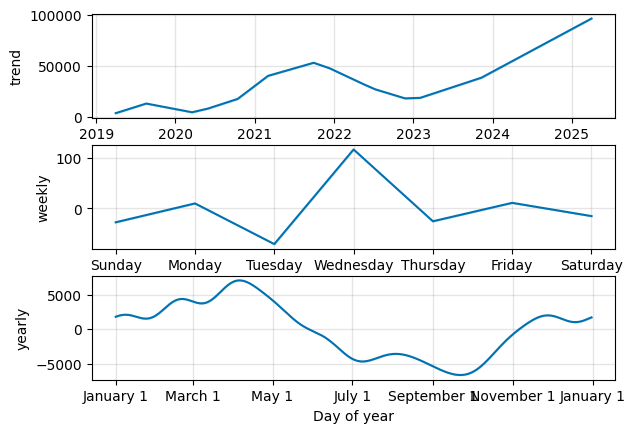

In [9]:
## Include seasonality in the fit
m = Prophet()
m.fit(df)
forecast = m.predict(df)
components = m.plot_components(forecast)
components.set_size_inches(6, 4)
components.show()

#### Change Points in the Trend

One of the innovations of prophet is the addition of change points in estimating the trend. We will expand on this next. In this first implementation, we didn't manually choose changepoints thus Prophet automatically specifies 25 uniformly-distributed changepoints within the first 80% of the data. The red lines indicate which of the changepoints were significant (non-zero). These represent the changepoints where the trend changed "enough" (note that this is not statistically significant statement) that Prophet did not zero these out (this is essentially just applying a Laplace prior or the regularization, which makes most of the changepoints zero except the most significant ones). See explanation in the description of the model.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/fz6x40ul.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/jwb_85c4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77981', 'data', 'file=/tmp/tmp5eduz8m0/fz6x40ul.json', 'init=/tmp/tmp5eduz8m0/jwb_85c4.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_model3kszq0qr/prophet_model-20251101200712.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:07:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


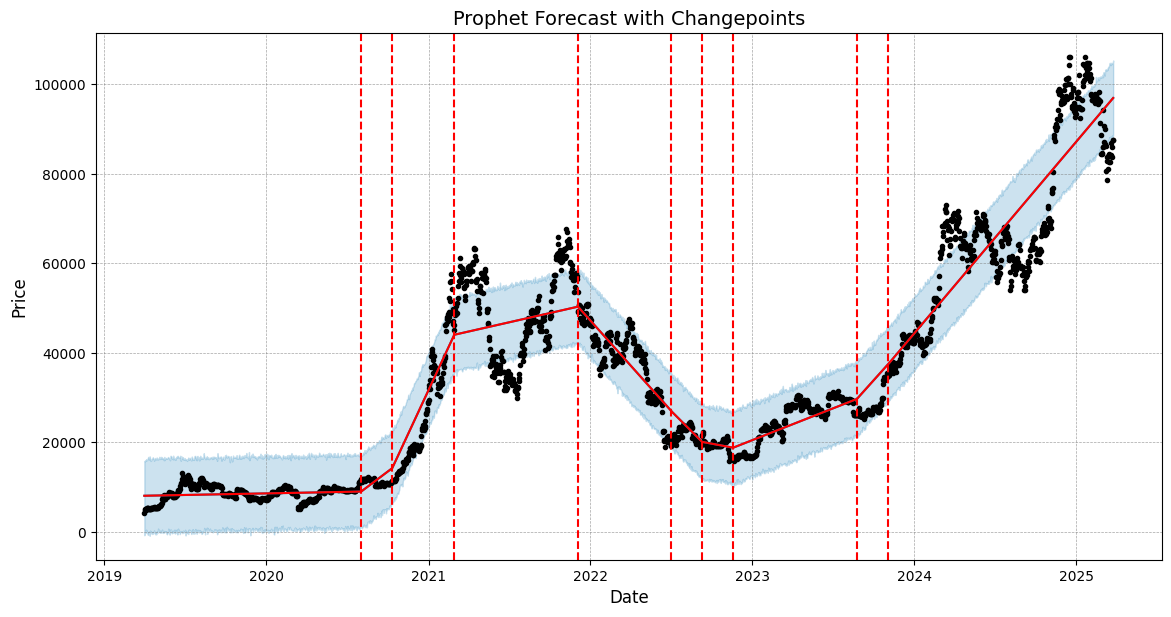

In [10]:

# Create the Prophet model without seasonality
m = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False
)

# Fit the model using only the training data
m.fit(train_data)

# Make predictions on the training data
forecast_train = m.predict(train_data)

# Plot the forecast using Prophet's built-in plot (keeps Prophet's style)
fig = m.plot(forecast_train)

# Standardize plot style: set figure size and layout
fig.set_size_inches(12, 6)  # consistent figure size (you can adjust this as needed)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Prophet Forecast with Changepoints', fontsize=14)

# Add changepoints to the plot
_ = add_changepoints_to_plot(fig.gca(), m, forecast_train)

# Optional: consistent grid style or other tweaks
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()


We can extract all 25 changepoints from the model. (Note: this doesn't tell us which of these changepoints were actually non-zero after the Laplace prior was applied).

In [11]:
changepoints = m.changepoints
print(changepoints)

70     2019-06-10
140    2019-08-19
210    2019-10-28
280    2020-01-06
349    2020-03-15
419    2020-05-24
489    2020-08-02
559    2020-10-11
629    2020-12-20
699    2021-02-28
769    2021-05-09
839    2021-07-18
908    2021-09-25
978    2021-12-04
1048   2022-02-12
1118   2022-04-23
1188   2022-07-02
1258   2022-09-10
1328   2022-11-19
1398   2023-01-28
1467   2023-04-07
1537   2023-06-16
1607   2023-08-25
1677   2023-11-03
1747   2024-01-12
Name: ds, dtype: datetime64[ns]


We can also specifically find the "significant" changepoints.

In [12]:
# first let's print the delta vector
delta = m.params['delta'][0]
print(delta)

[-9.98874e-08 -1.10219e-07 -9.81163e-08  9.26588e-08  3.49983e-05
  3.47669e-07  1.49745e+00  2.84938e+00  4.12853e-06 -3.92268e+00
 -1.57352e-07  3.98265e-05 -3.10054e-08 -2.74920e+00 -9.69781e-08
 -1.70360e-07  2.51423e-01  1.65299e+00  1.18466e+00 -5.13362e-08
  8.75789e-08 -1.50269e-07  1.46054e+00  1.50752e-01  1.29456e-07]


As we can see, most of these values are approximately 0, except for a few that are significantly different from 0.

In [14]:
# choose a threshold that excludes the almost-zero changepoints
significant_changepoints = m.changepoints[np.abs(delta) > 0.00001]
print(significant_changepoints)

349    2020-03-15
489    2020-08-02
559    2020-10-11
699    2021-02-28
839    2021-07-18
978    2021-12-04
1188   2022-07-02
1258   2022-09-10
1328   2022-11-19
1607   2023-08-25
1677   2023-11-03
Name: ds, dtype: datetime64[ns]


These are the 11 changepoints that Prophet has determined to be significantly different from 0.

We can also graph the delta vector to understand the magnitude of the non-zero "significant" changepoints.

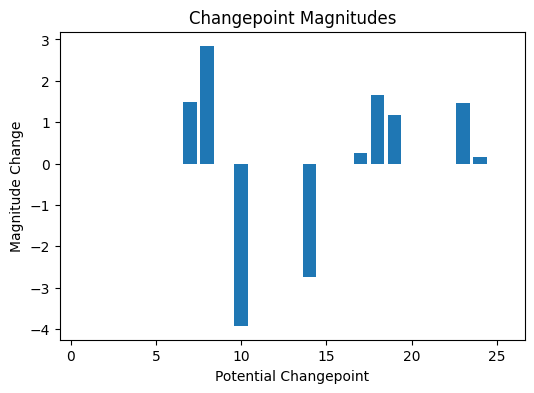

In [15]:
deltas = np.mean(m.params['delta'], axis=0)
delta_df = pd.DataFrame({'Potential_Changepoint': range(1, len(deltas) + 1), 'Magnitude_Change': deltas})

plt.figure(figsize=(6, 4))
plt.bar(delta_df['Potential_Changepoint'], delta_df['Magnitude_Change'])
plt.xlabel('Potential Changepoint')
plt.ylabel('Magnitude Change')
plt.title('Changepoint Magnitudes')
plt.show()


This plot also helps visualize which of the changepoints are non-zero.

Prophet gives us the option to modify the default number of changepoints (25 in this implementation) using the n_changepoints parameter of the prophet() function. However, if the trend is overfit or underfit, Prophet documentation recommends adjusting the strength parameter of the sparse prior using changepoint_prior_scale, which has a default value of 0.05. Increasing it will make the trend (and the model) more flexible (overfit to the data) by finding more changepoints, and decreasing it will make the model less flexible (underfit to the data) by identifying less changepoints.

Here, we compare changepoint.prior.scale = 0.05 vs. 0.005.

### Comparison of Changepoint Prior Scale

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/xu1j0nfh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/ly92twjd.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76821', 'data', 'file=/tmp/tmp5eduz8m0/xu1j0nfh.json', 'init=/tmp/tmp5eduz8m0/ly92twjd.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelbtdpflbu/prophet_model-20251101200729.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:07:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/5zzhyuxr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/oq3puivc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

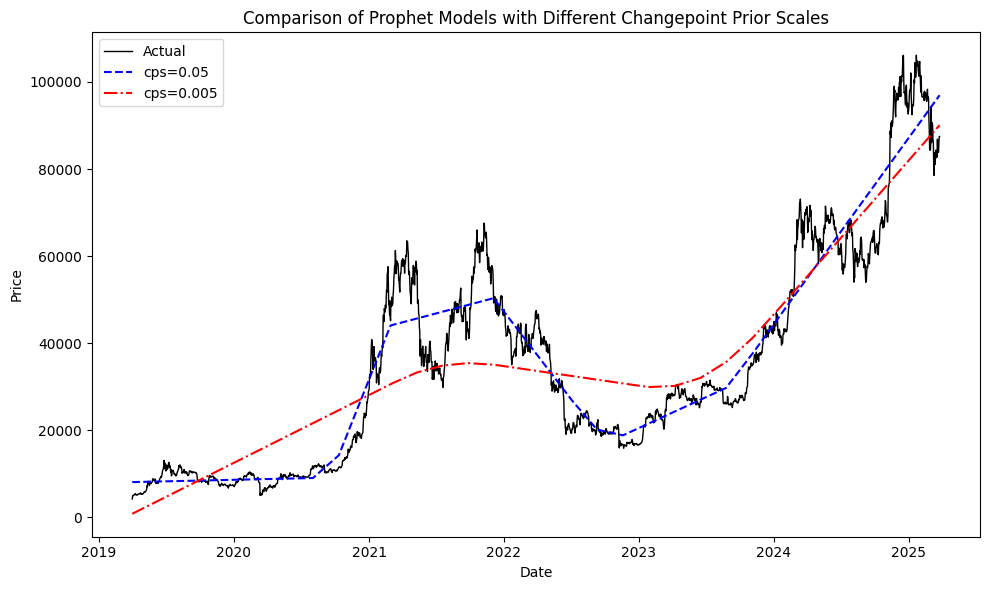

In [16]:

# Fit the first Prophet model with changepoint_prior_scale=0.05
model1 = Prophet(
    changepoint_prior_scale=0.05,
    weekly_seasonality=False,
    yearly_seasonality=False
)
model1.fit(train_data)
forecast1 = model1.predict(train_data)

# Fit the second Prophet model with changepoint_prior_scale=0.005
model2 = Prophet(
    changepoint_prior_scale=0.005,
    weekly_seasonality=False,
    yearly_seasonality=False
)
model2.fit(train_data)
forecast2 = model2.predict(train_data)

# 3️ Plot both forecasts on the same figure
plt.figure(figsize=(10, 6))

# Plot the actual data
plt.plot(train_data['ds'], train_data['y'], label='Actual', color='black', linewidth=1)

# Plot forecasts
plt.plot(forecast1['ds'], forecast1['yhat'], label='cps=0.05', linestyle='--', color='blue')
plt.plot(forecast2['ds'], forecast2['yhat'], label='cps=0.005', linestyle='-.', color='red')

# 4️ Add labels and legend
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Comparison of Prophet Models with Different Changepoint Prior Scales')
plt.legend()

plt.tight_layout()
plt.show()


As we can see, with a lower value for the strength parameter in the second plot, the model curve is less flexible and thus results in worse fit to the data. We thus stick with changepoint.prior.scale = 0.05 since the model fits the data much better with this scale parameter.

### Comparison of Automatic vs. Manual Changepoint

Since Prophet is uniformly placing the changepoints in automatic changepoint detection, these changepoints may not accurately reflect where the trend is significantly changing. Therefore, Prophet provides an option to manually define changepoints. We can use our knowledge of the market to better select changepoints.

Based on market analysis, the following points in time were identified at which the trend may change. Note that compared to holidays, these dates represent shifts in the overall trend of the data. Changepoints capture structural breaks, such as a change from a bullish to a bearish trend or vice versa. They are often unexpected events or regime changes that cause a sustained, long-term shift in the trend of the time series. They are not recurrent (unlike holidays)!

1. March 12, 2020 – COVID-19 Pandemic Crash
Event: Bitcoin's price dropped significantly as global markets reacted to the COVID-19 pandemic.
Date: March 12, 2020
2. December 16, 2020 – Bitcoin Breaks Previous All-Time High
Event: Bitcoin surpassed its 2017 all-time high, leading to a strong bullish trend.
Date: December 16, 2020
3. May 19, 2021 – China’s Bitcoin Mining Ban
Event: Bitcoin’s price dropped sharply after China's crackdown on Bitcoin mining, starting a major correction.
Date: May 19, 2021
4. November 10, 2021 – Bitcoin Peaks at \$69,000
Event: Bitcoin reached its all-time high price of approximately \$69,000 before beginning a bearish phase.
Date: November 10, 2021
5. May 9, 2022 – Terra (LUNA) Crash and Crypto Market Meltdown
Event: The collapse of Terra’s ecosystem triggered a significant decline in the entire crypto market, including Bitcoin.
Date: May 9, 2022
6. November 11, 2022 – FTX Collapse
Event: FTX filed for bankruptcy, leading to a major crash in the cryptocurrency market.
Date: November 11, 2022
7. March 13, 2023 – Banking Crisis and Bitcoin’s Surge
Event: Following the collapse of Silicon Valley Bank and other financial institutions, Bitcoin surged as a perceived safe haven.
Date: March 13, 2023
8. December 5, 2024 – Bitcoin Surpasses $100,000 for the First Time
Event: Following Donald Trump's victory in the U.S. presidential election, Bitcoin's price surpassed \$100,000 for the first time, setting a new all-time high.
Date: December 5, 2024



DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/_jqkk4jm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/ykgng492.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=15858', 'data', 'file=/tmp/tmp5eduz8m0/_jqkk4jm.json', 'init=/tmp/tmp5eduz8m0/ykgng492.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelotjt88b0/prophet_model-20251101200735.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:07:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
20:07:35 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/qoakz4g0.json
DE

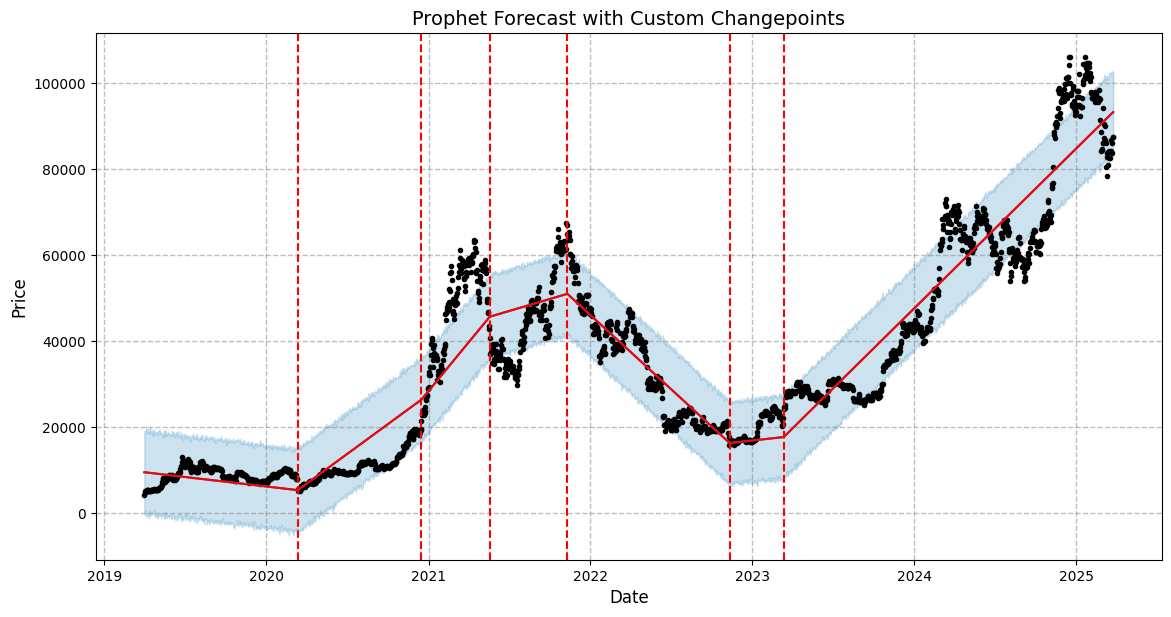

In [17]:

# Train Prophet model with custom changepoints and no seasonality on training data
m = Prophet(
    changepoint_prior_scale=0.05,
    changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ],
    weekly_seasonality=False,
    yearly_seasonality=False
)

# Fit the model using only the training data
m.fit(train_data)

# Make predictions on the training data
forecast_train = m.predict(train_data)

# Plot the forecast using Prophet's built-in plot style
fig = m.plot(forecast_train)

# Set consistent figure size for visual consistency
fig.set_size_inches(12, 6)

# Add changepoints (trend breakpoints) to the plot
_ = add_changepoints_to_plot(fig.gca(), m, forecast_train)

# Optional: add consistent labels and grid
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Prophet Forecast with Custom Changepoints', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()


As we can see, Prophet has identified 6 of the 8 changepoints that we specified to be significant. This is because even with manual changepoints, Prophet is still applying regularization through changepoint_prior_scale to ensure that the model doesn't overfit by adding too many changepoints. Only the points in time when the trend changes the most drastically are significant changepoints. Let's see which changepoints Prophet has identified significant.

In [18]:
delta = m.params['delta'][0]
significant_changepoints = m.changepoints[np.abs(delta) > 0.005]
print(significant_changepoints)


0   2020-03-12
1   2020-12-16
2   2021-05-19
3   2021-11-10
5   2022-11-11
6   2023-03-13
Name: ds, dtype: datetime64[ns]


The selected changepoints are:

1. COVID-19 Pandemic Market Crash (March 12, 2020)
2. Bitcoin breaks above 20,000 for the first time ever (December, 16,2020)
3. China’s Bitcoin Mining Ban (May 19, 2021)
4. Bitcoin All-Time High at 69,000 (November 10, 2021)
5. FTX Collapse (November 11, 2022)
6. Banking Crisis and Bitcoin as a Safe Haven (March 13, 2023)


Note that the last event, when the bitcoin surprassed $100,000 end of 2024 is not selected using regularized regression. However, all eight events would be selected if we choose the scale to be 0.005, a rather small scale, indicating that we might select all eight change points.

If we want the model to identify more changepoints (more flexibility), we can adjust the changepoint.prior.scale parameter as before; a higher value will result in more changepoints.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/8wqk410k.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/eciu6qec.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=32664', 'data', 'file=/tmp/tmp5eduz8m0/8wqk410k.json', 'init=/tmp/tmp5eduz8m0/eciu6qec.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelgzwqbd0h/prophet_model-20251101200744.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:07:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


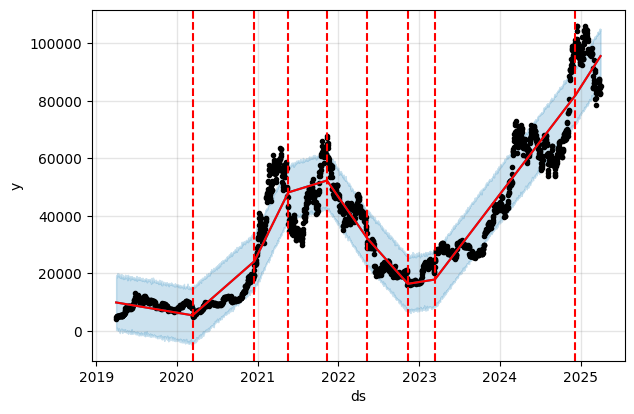

In [19]:

m = Prophet(changepoint_prior_scale = 0.3, changepoints=['2020-03-12', '2020-12-16', '2021-05-19', '2021-11-10', '2022-05-09', '2022-11-11', '2023-03-13', '2024-12-05'],weekly_seasonality = False, yearly_seasonality = False)
m.fit(df)
forecast = m.predict(df)
plot = m.plot(forecast)
plot.set_size_inches(6, 4)
a = add_changepoints_to_plot(plot.gca(), m, forecast)

With a larger scale value, Prophet identified all changepoints as signficant. Because we know a prior that December 2025 was a turning point for bitcoin price we can keep that change point in the further analysis.

### Evaluation of Prediction Accuracy for Automatic vs Custom Change Points

Next we will evaluate how the selection of the change points impact the prediction accuracy.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/63nxu6k6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/jil4rzik.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87193', 'data', 'file=/tmp/tmp5eduz8m0/63nxu6k6.json', 'init=/tmp/tmp5eduz8m0/jil4rzik.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modeljgvrhyn2/prophet_model-20251101200748.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:07:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/83dq5xrk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/k_yydbfh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

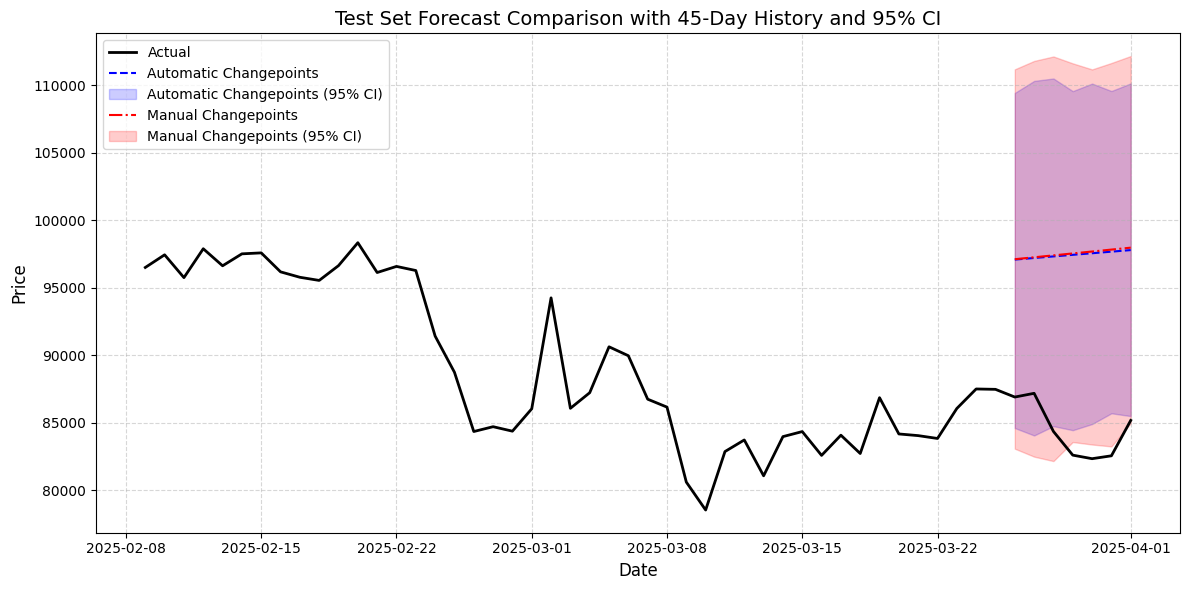

=== Automatic Changepoints Performance ===
MSPE: 173129216.4169
MAE:  12995.4073
MAPE: 0.1545
PM:   47.5431
----------------------------------------
=== Manual Changepoints Performance ===
MSPE: 175980222.6371
MAE:  13099.0786
MAPE: 0.1558
PM:   48.3261
----------------------------------------


In [20]:
# Define the look-back period (45 days)
lookback_days = 45

# Identify the start date for the look-back period
lookback_start_date = test_data['ds'].min() - pd.Timedelta(days=lookback_days)

# Filter the actual data to include the 45-day window before the test period
actual_window = df[(df['ds'] >= lookback_start_date) & (df['ds'] <= test_data['ds'].max())].reset_index(drop=True)

# Fit Model 1: changepoint_prior_scale=0.05
model_cps = Prophet(
    changepoint_prior_scale=0.05,
    weekly_seasonality=False,
    yearly_seasonality=False,
    interval_width=0.95  # Set confidence interval to 95%
)
model_cps.fit(train_data)
forecast_cps = model_cps.predict(test_data)

# Fit Model 2: manual changepoints
model_manual = Prophet(
    changepoint_prior_scale=0.3,
    changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ],
    weekly_seasonality=False,
    yearly_seasonality=False,
    interval_width=0.95  # Set confidence interval to 95%
)
model_manual.fit(train_data)
forecast_manual = model_manual.predict(test_data)

# Plot the actual data and forecasts
plt.figure(figsize=(12, 6))

# Plot actual data (historical 45 days + test period)
plt.plot(actual_window['ds'], actual_window['y'], label='Actual', color='black', linewidth=2)

# Plot Model 1 forecast
plt.plot(forecast_cps['ds'], forecast_cps['yhat'], label='Automatic Changepoints', linestyle='--', color='blue')
plt.fill_between(
    forecast_cps['ds'],
    forecast_cps['yhat_lower'],
    forecast_cps['yhat_upper'],
    color='blue',
    alpha=0.2,
    label='Automatic Changepoints (95% CI)'
)

# Plot Model 2 forecast
plt.plot(forecast_manual['ds'], forecast_manual['yhat'], label='Manual Changepoints', linestyle='-.', color='red')
plt.fill_between(
    forecast_manual['ds'],
    forecast_manual['yhat_lower'],
    forecast_manual['yhat_upper'],
    color='red',
    alpha=0.2,
    label='Manual Changepoints (95% CI)'
)

#  Add labels and legend
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Test Set Forecast Comparison with 45-Day History and 95% CI', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

# Evaluate Model 1 (changepoint_prior_scale=0.05)
evaluate_performance(
    true=test_data['y'],
    pred=forecast_cps['yhat'],
    model_name="Automatic Changepoints"
)

# Evaluate Model 2 (manual changepoints)
evaluate_performance(
    true=test_data['y'],
    pred=forecast_manual['yhat'],
    model_name="Manual Changepoints"
)



After comparison, we decided to use manual changepoints in the subsequent analyses

## Seasonality Component

Let's plot the seasonality components of prophet_plot_components().

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/w7o_38u9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/owvjl8w6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1393', 'data', 'file=/tmp/tmp5eduz8m0/w7o_38u9.json', 'init=/tmp/tmp5eduz8m0/owvjl8w6.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_model7gg2ajkm/prophet_model-20251101200802.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:08:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:08:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


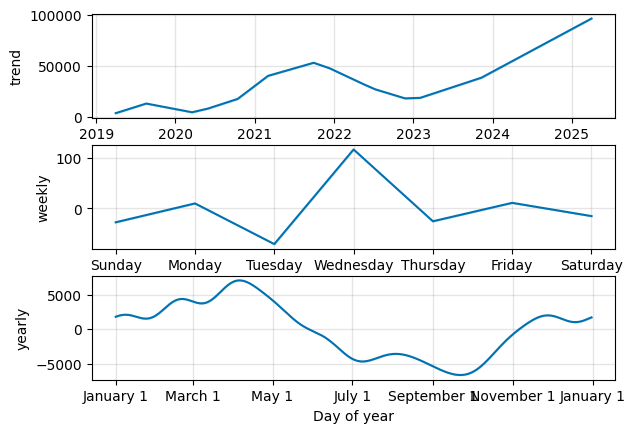

In [21]:
m = Prophet()
m.fit(df)
forecast = m.predict(df)
components = m.plot_components(forecast)
components.set_size_inches(6, 4)
components.show()

There seem to be some variations in the seasonality, both for days-of-the-week and months-of-the-year when bitcoin prices peak, as the graph fluctuates/doesn't stay constant. This indicates that there could be a significant weekly or/and yearly seasonality.

We can determine if the types of seasonality are significant using cross-validation and comparing the RMSE, MAPE, and MAE values. These are all just performance metrics for our model, and a smaller value for each of these indicates a smaller error, which means better performance of the model.

We compare 4 models:

* Model 1: No yearly or weekly seasonality
* Model 2: Only weekly seasonality
* Model 3: Only yearly seasonality
* Model 4: Both weekly and yearly seasonality

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/de17khdl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/z09rktnw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45753', 'data', 'file=/tmp/tmp5eduz8m0/de17khdl.json', 'init=/tmp/tmp5eduz8m0/z09rktnw.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelonoe27z5/prophet_model-20251101200833.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:08:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:08:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/z_m23gw7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/nm4lioex.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

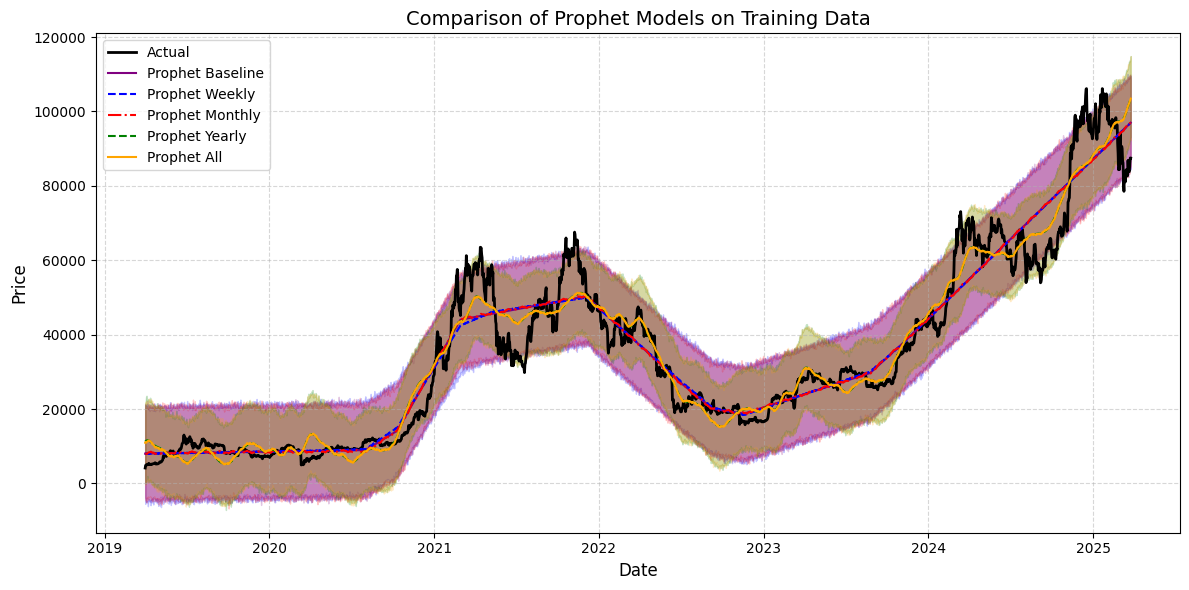

=== Prophet Baseline Performance ===
MSPE: 40933220.8640
MAE:  4552.2369
MAPE: 0.1411
PM:   0.0684
----------------------------------------
=== Prophet Weekly Performance ===
MSPE: 42001458.0235
MAE:  4605.3641
MAPE: 0.1429
PM:   0.0702
----------------------------------------
=== Prophet Monthly Performance ===
MSPE: 40732637.7774
MAE:  4552.7247
MAPE: 0.1420
PM:   0.0681
----------------------------------------
=== Prophet Yearly Performance ===
MSPE: 30933728.3456
MAE:  4171.5485
MAPE: 0.1664
PM:   0.0517
----------------------------------------
=== Prophet All Performance ===
MSPE: 30862105.2761
MAE:  4173.6694
MAPE: 0.1661
PM:   0.0516
----------------------------------------


In [23]:
# ========== Step 1. Train models ==========
trained_models = []

model_specs = [
    ("Prophet Baseline", Prophet(yearly_seasonality=False, weekly_seasonality=False, interval_width=0.95)),
    ("Prophet Weekly", Prophet(yearly_seasonality=False, weekly_seasonality=True, interval_width=0.95)),
    ("Prophet Monthly", Prophet(yearly_seasonality=False, weekly_seasonality=False, interval_width=0.95).add_seasonality(name='monthly', period=30.5, fourier_order=5)),
    ("Prophet Yearly", Prophet(yearly_seasonality=True, weekly_seasonality=False, interval_width=0.95)),
    ("Prophet All", Prophet(yearly_seasonality=True, weekly_seasonality=True,  interval_width=0.95).add_seasonality(name='monthly', period=30.5, fourier_order=5))
]

for model_name, model in model_specs:
    trained_model = model.fit(train_data.copy())
    trained_models.append((model_name, trained_model))

# ========== Step 2. Predict on Training Data and Save Forecast ==========
forecast_results = []
for model_name, model in trained_models:
    forecast = model.predict(train_data.copy())
    forecast_results.append((model_name, forecast))

# ========== Step 3. Plot Forecasts on Training Data ==========
plt.figure(figsize=(12, 6))
plt.plot(train_data['ds'], train_data['y'], color='black', label='Actual', linewidth=2)

colors = ['purple', 'blue', 'red', 'green', 'orange']
linestyles = ['-','--', '-.', '--', '-']

for idx, (model_name, forecast) in enumerate(forecast_results):
    plt.plot(
        forecast['ds'],
        forecast['yhat'],
        label=model_name,
        linestyle=linestyles[idx],
        color=colors[idx]
    )
    plt.fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        color=colors[idx],
        alpha=0.2
    )

plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Comparison of Prophet Models on Training Data', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ========== Step 4. Evaluate Performance ==========

for model_name, forecast in forecast_results:
    merged = pd.merge(train_data, forecast[['ds', 'yhat']], on='ds', how='left')
    evaluate_performance(merged['y'], merged['yhat'], model_name)



=== Test Set Evaluation ===
=== Prophet Baseline Performance ===
MSPE: 173129216.4169
MAE:  12995.4073
MAPE: 0.1545
PM:   47.5431
----------------------------------------
=== Prophet Weekly Performance ===
MSPE: 173563184.0317
MAE:  13013.6946
MAPE: 0.1547
PM:   47.6623
----------------------------------------
=== Prophet Monthly Performance ===
MSPE: 167988998.8407
MAE:  12795.7226
MAPE: 0.1522
PM:   46.1316
----------------------------------------
=== Prophet Yearly Performance ===
MSPE: 418889947.0415
MAE:  20337.5341
MAPE: 0.2416
PM:   115.0317
----------------------------------------
=== Prophet All Performance ===
MSPE: 411323806.8691
MAE:  20150.9865
MAPE: 0.2394
PM:   112.9539
----------------------------------------


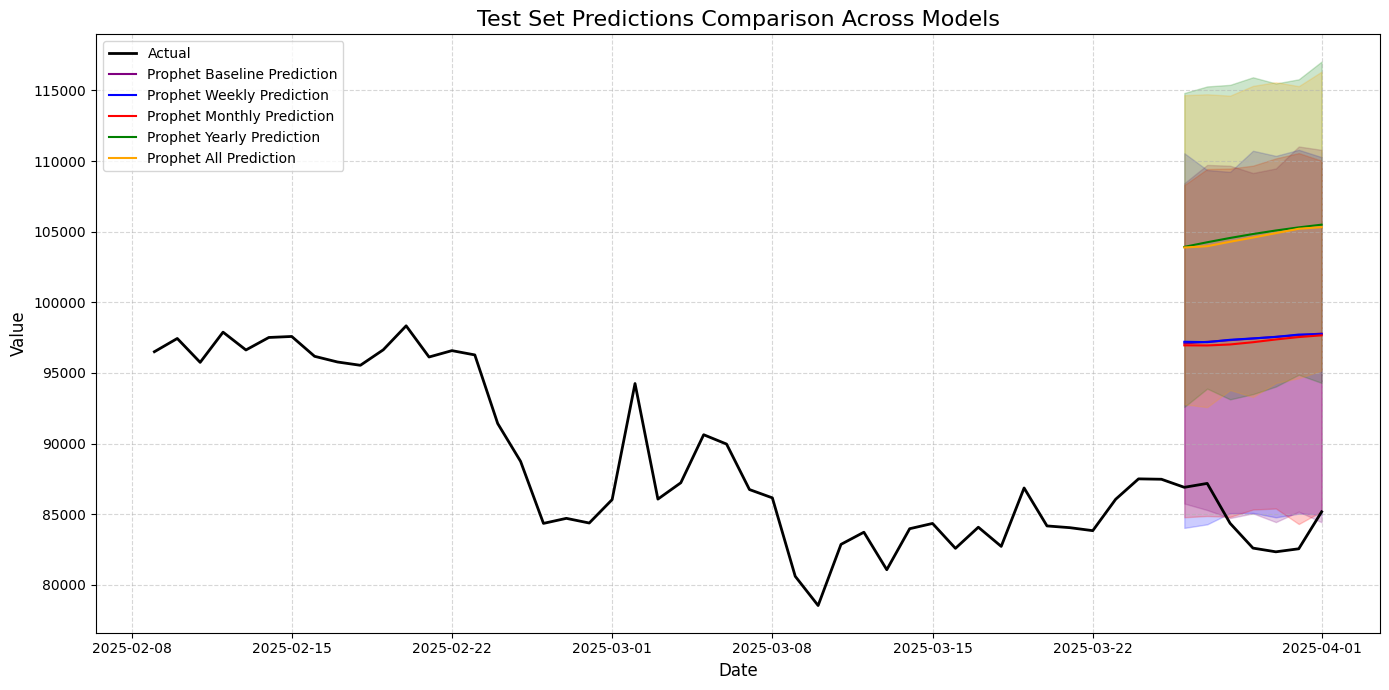

In [24]:

# ========== Step 5. Extend actual data for test visualization ==========
actual_extended = pd.concat([train_data.tail(45), test_data], ignore_index=True)

# ========== Step 6. Predict on Test Set ==========
test_predictions = []
for model_name, model in trained_models:
    forecast_test = model.predict(test_data.copy())
    test_predictions.append((model_name, forecast_test))

# ========== Step 7. Evaluate Performance on Test Set ==========
print("\n=== Test Set Evaluation ===")
for model_name, forecast_test in test_predictions:
    evaluate_performance(test_data['y'], forecast_test['yhat'], model_name)

# ========== Step 8. Plot Predictions on Test Set ==========
plt.figure(figsize=(14, 7))
plt.plot(actual_extended['ds'], actual_extended['y'], label='Actual', color='black', linewidth=2)

for idx, (model_name, forecast_test) in enumerate(test_predictions):
    plt.plot(
        forecast_test['ds'],
        forecast_test['yhat'],
        label=f'{model_name} Prediction',
        color=colors[idx],
        linewidth=1.5
    )
    plt.fill_between(
        forecast_test['ds'],
        forecast_test['yhat_lower'],
        forecast_test['yhat_upper'],
        color=colors[idx],
        alpha=0.2
    )

plt.title('Test Set Predictions Comparison Across Models', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Based on the analysis, the model without seasonality performs well, and considering weekly improves the model's performance but not significantly

#### Is seasonality statistically significant?

The main purpose of using regression analysis here is to assess the significance and importance of different seasonal factors (such as weekday, month, and year) on the target variable Bitcoin price.

In [25]:


# ========== Step 1. Prepare regression inputs ==========
# Generate time step index
time_pts = np.arange(1, len(train_data) + 1)

# Extract weekday, month, and year from the date
train_data = train_data.copy()  # Defensive copy to avoid modifying the original
train_data['week_day'] = train_data['ds'].dt.weekday
train_data['month'] = train_data['ds'].dt.month
train_data['year'] = train_data['ds'].dt.year

# ========== Step 2. Build X and y ==========
X = np.column_stack([
    time_pts,                  # Trend
    train_data['week_day'],    # Weekday
    train_data['month'],       # Month
    train_data['year']         # Year
])
y = train_data['y'].values

# ========== Step 3. Fit GAM ==========
# Example: trend + weekday + month + year effects
gam = LinearGAM(
    s(0) + f(1) + f(2) + f(3)
).fit(X, y)

# ========== Step 4. Print model summary ==========
print(gam.summary())



LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     35.6917
Link Function:                     IdentityLink Log Likelihood:                                -39253.3779
Number of Samples:                         2186 AIC:                                            78580.1392
                                                AICc:                                           78581.4267
                                                GCV:                                         25843279.1024
                                                Scale:                                       25084883.0348
                                                Pseudo R-Squared:                                   0.9588
Feature Function                  Lam

The regression results using GAM model are consistent with the Prophet results, showing that the weekly seasonality is not significant in explaining Bitcoin price fluctuations.

We also evaluate using OLS to test whether each seasonal component is significant or not:

In [26]:
time_pts = np.arange(1, len(mydates) + 1)

# # Ensure 'mydates' is in datetime format
# mydates = pd.to_datetime(mydates)

# Extract week day and month using the .dt accessor
week_day = mydates.dt.strftime('%A')
month = mydates.dt.strftime('%b')
year = mydates.dt.year

# DataFrame for modeling
data = pd.DataFrame({
    'time_pts': time_pts,
    'week_day': week_day,
    'month': month,
    'pricebtc': pricebtc
})

# Fit GAM model with weekday
model_week = ols('pricebtc ~ time_pts + C(week_day)', data=data).fit()
print(model_week.summary())

# Fit GAM model with month
model_month = ols('pricebtc ~ time_pts + C(month)', data=data).fit()
print(model_month.summary())

#  Fit GAM model with year
model_year = ols('pricebtc ~ time_pts + C(year)', data=data).fit()
print("\n=== Model with Year ===")
print(model_year.summary())

                            OLS Regression Results                            
Dep. Variable:               pricebtc   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     1139.
Date:                Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:08:51   Log-Likelihood:                -42547.
No. Observations:                3873   AIC:                         8.511e+04
Df Residuals:                    3865   BIC:                         8.516e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

None of the days of the week are statistically significant, indicateing that the OLS does not detect significant weekly seasonality, a similar result as provided by the Prophet model.

Moreover, the year-based model explains a substantial portion of the variation in Bitcoin prices (R² = 0.925), indicating that long-term yearly trends play a dominant role in price movements.


Given the analysis above, we will consider no seasonality in the Prophet model for the remaining of the analysis.

## Holiday Component

Prophet does not automatically account for holidays, so we must manually specify the holidays that we want to include. Let's say that we've identified two bitcoin-specific holidays that may affect the bitcoin price: Bitcoin Halving Day and Genesis Block Day. We can tell Prophet to consider the effects of these holidays. Here, we test the significance of adding these holidays.

NOTE: These holidays, such as Halving Day and Genesis Block Day are holidays and NOT potential changepoints because they are recurrent, temporary deviations from the trend with short-term effects for a limited period (compared to a significant changepoint, which affects the long-term trend).

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/yo9eo1rn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/cs13ptjw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=22454', 'data', 'file=/tmp/tmp5eduz8m0/yo9eo1rn.json', 'init=/tmp/tmp5eduz8m0/cs13ptjw.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelastv265e/prophet_model-20251101200854.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:08:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:08:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
20:08:54 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/9kdrxb6d.json
DE


=== Train Data Evaluation ===
=== No Holidays Performance ===
MSPE: 56082515.3916
MAE:  5779.3582
MAPE: 0.2100
PM:   0.0937
----------------------------------------
=== Bitcoin Holidays Performance ===
MSPE: 55999393.4724
MAE:  5778.5348
MAPE: 0.2102
PM:   0.0936
----------------------------------------
=== US Holidays Performance ===
MSPE: 55461423.1221
MAE:  5743.7411
MAPE: 0.2086
PM:   0.0927
----------------------------------------


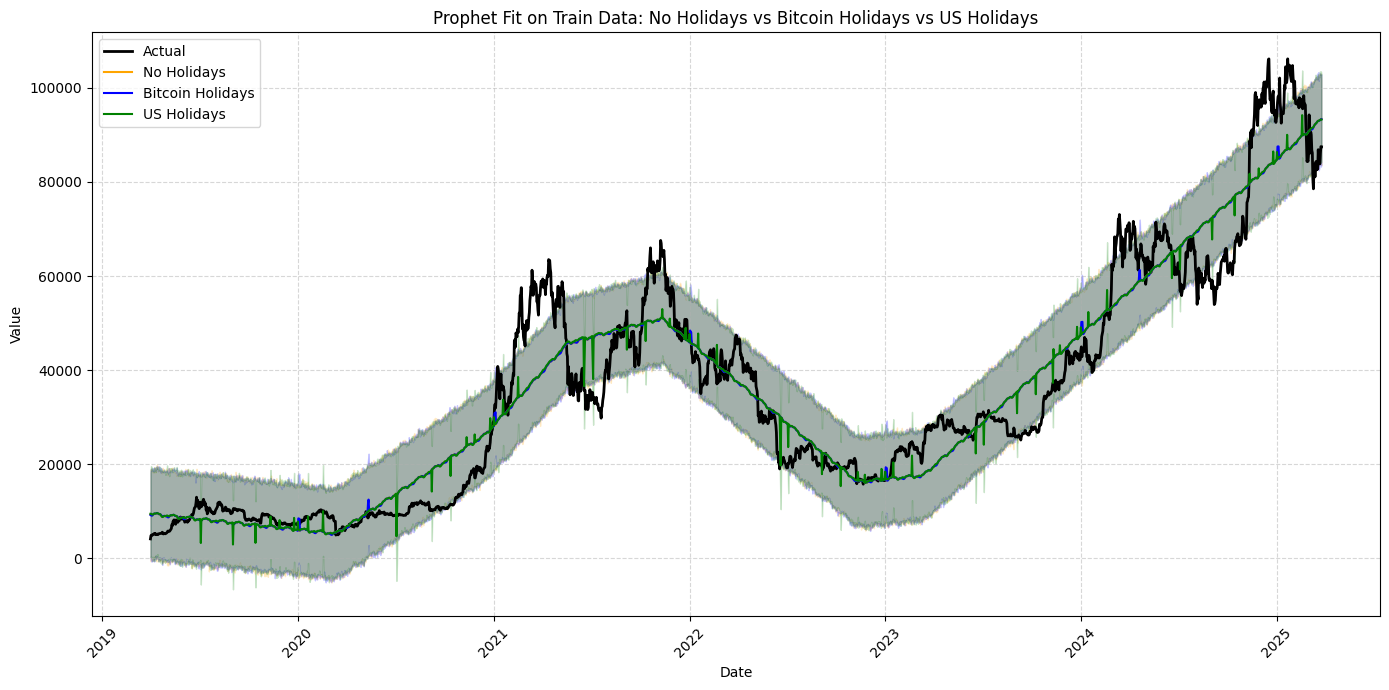

In [27]:

# ========== Define Bitcoin Holidays ==========
bitcoin_halving = pd.DataFrame({
    'holiday': 'bitcoin_halving',
    'ds': pd.to_datetime(['2020-05-11', '2024-04-19']),
    'lower_window': 0,
    'upper_window': 1
})

genesis_block = pd.DataFrame({
    'holiday': 'genesis_block',
    'ds': pd.to_datetime([
        '2019-01-03', '2020-01-03', '2021-01-03',
        '2022-01-03', '2023-01-03', '2024-01-03', '2025-01-03'
    ]),
    'lower_window': -1,
    'upper_window': 1
})

holidays_bitcoin = pd.concat([bitcoin_halving, genesis_block])

# ========== Model A: No Holidays ==========
m_no_holidays = Prophet(yearly_seasonality=False, weekly_seasonality=False,     changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ]).add_seasonality(name='monthly', period=30.5, fourier_order=5)
m_no_holidays.fit(train_data)
forecast_no_holidays = m_no_holidays.predict(train_data)

# ========== Model B: Bitcoin Holidays ==========
m_bitcoin_holidays = Prophet(
    holidays=holidays_bitcoin,
    yearly_seasonality=False,
    weekly_seasonality=False,     changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ]
).add_seasonality(name='monthly', period=30.5, fourier_order=5)
m_bitcoin_holidays.fit(train_data)
forecast_bitcoin_holidays = m_bitcoin_holidays.predict(train_data)

# ========== Model C: US Holidays ==========
m_us_holidays = Prophet(yearly_seasonality=False, weekly_seasonality=False,     changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ]).add_seasonality(name='monthly', period=30.5, fourier_order=5)
m_us_holidays.add_country_holidays(country_name='US')
m_us_holidays.fit(train_data)
forecast_us_holidays = m_us_holidays.predict(train_data)

# ========== Evaluate Performance on Train Data ==========
print("\n=== Train Data Evaluation ===")
evaluate_performance(train_data['y'], forecast_no_holidays['yhat'], "No Holidays")
evaluate_performance(train_data['y'], forecast_bitcoin_holidays['yhat'], "Bitcoin Holidays")
evaluate_performance(train_data['y'], forecast_us_holidays['yhat'], "US Holidays")

# ========== Plot Actual and Forecasts ==========
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(train_data['ds'], train_data['y'], label='Actual', color='black', linewidth=2)

# Plot No Holidays
plt.plot(train_data['ds'], forecast_no_holidays['yhat'], label='No Holidays', color='orange')
plt.fill_between(train_data['ds'], forecast_no_holidays['yhat_lower'], forecast_no_holidays['yhat_upper'],
                 color='orange', alpha=0.2)

# Plot Bitcoin Holidays
plt.plot(train_data['ds'], forecast_bitcoin_holidays['yhat'], label='Bitcoin Holidays', color='blue')
plt.fill_between(train_data['ds'], forecast_bitcoin_holidays['yhat_lower'], forecast_bitcoin_holidays['yhat_upper'],
                 color='blue', alpha=0.2)

# Plot US Holidays
plt.plot(train_data['ds'], forecast_us_holidays['yhat'], label='US Holidays', color='green')
plt.fill_between(train_data['ds'], forecast_us_holidays['yhat_lower'], forecast_us_holidays['yhat_upper'],
                 color='green', alpha=0.2)

# Plot formatting
plt.title("Prophet Fit on Train Data: No Holidays vs Bitcoin Holidays vs US Holidays")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



=== Test Set Evaluation ===
=== No Holidays Performance ===
MSPE: 86863810.3114
MAE:  9093.2342
MAPE: 0.1083
PM:   23.8537
----------------------------------------
=== Bitcoin Holidays Performance ===
MSPE: 86617125.8205
MAE:  9079.9254
MAPE: 0.1081
PM:   23.7860
----------------------------------------
=== US Holidays Performance ===
MSPE: 85017797.2904
MAE:  8985.3664
MAPE: 0.1070
PM:   23.3468
----------------------------------------


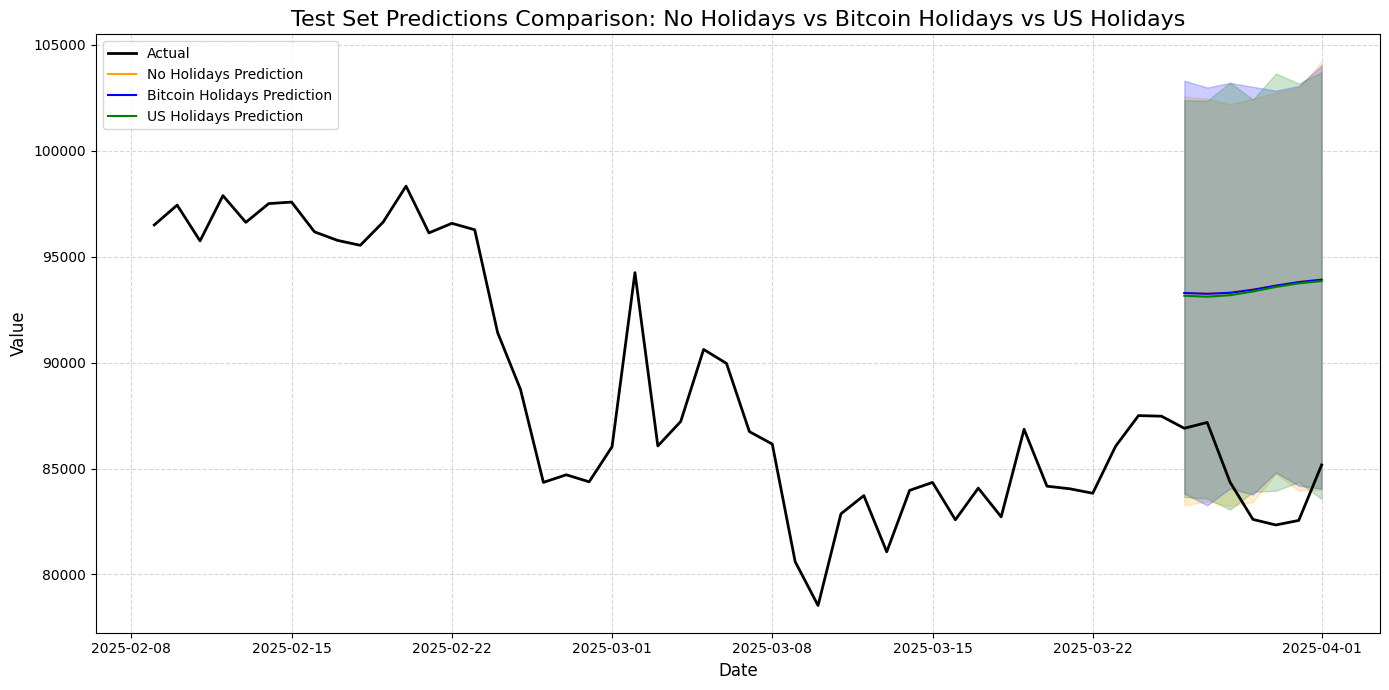

In [28]:
# ========== Step 1. Extend actual data ==========
# Add 45-day historical window before test set for better context
actual_extended = pd.concat([train_data.tail(45), test_data], ignore_index=True)

# ========== Step 2. Make predictions on test set ==========
# Prepare a list to store test predictions from each model
test_predictions = []

# List of trained models and their names
models = [
    ("No Holidays", m_no_holidays),
    ("Bitcoin Holidays", m_bitcoin_holidays),
    ("US Holidays", m_us_holidays)
]

# Loop through each model and generate test set predictions
for model_name, model in models:
    forecast = model.predict(test_data)
    test_predictions.append((model_name, forecast))

# ========== Step 3. Evaluate model performance ==========
print("\n=== Test Set Evaluation ===")
for model_name, forecast in test_predictions:
    evaluate_performance(test_data['y'], forecast['yhat'], model_name)

# ========== Step 4. Plot actual data and all model predictions ==========
plt.figure(figsize=(14, 7))

# Plot actual data (extended with historical 45 days)
plt.plot(actual_extended['ds'], actual_extended['y'], label='Actual', color='black', linewidth=2)

# Define consistent colors for models
colors = ['orange', 'blue', 'green']

# Loop through each model's forecast and plot predictions
for idx, (model_name, forecast) in enumerate(test_predictions):
    # Plot forecasted trend line
    plt.plot(
        forecast['ds'],
        forecast['yhat'],
        label=f'{model_name} Prediction',
        color=colors[idx],
        linewidth=1.5
    )

    # Plot 95% confidence interval as shaded region
    plt.fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        color=colors[idx],
        alpha=0.2
    )

# Add plot labels and title
plt.title('Test Set Predictions Comparison: No Holidays vs Bitcoin Holidays vs US Holidays', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()


Including US holidays results in slight improvements across all evaluation metrics. However, the relative gains are all very low, indicating that while US holidays or Bitcoin Holidays may have a minor influence on Bitcoin prices, their overall impact on model performance is limited and not substantial.

Let's say that these US holidays were significant. We could see the effects of these holidays with the holiday component of plot_components().

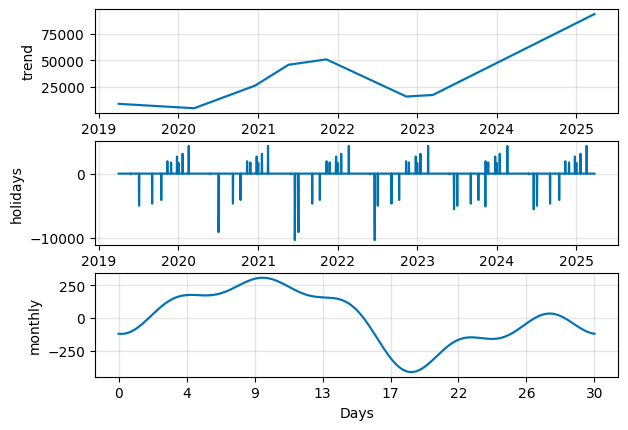

In [29]:
components = m_us_holidays.plot_components(forecast_us_holidays)
components.set_size_inches(6, 4)
components.show()

We can also print out all the holidays that the model is accounting for.

In [30]:
m_us_holidays.train_holiday_names

,0
0,New Year's Day
1,Memorial Day
2,Independence Day
3,Labor Day
4,Veterans Day
5,Thanksgiving Day
6,Christmas Day
7,Martin Luther King Jr. Day
8,Washington's Birthday
9,Columbus Day


Therefore, we do not include any holidays as we did not find any significant ones.

## Regression Analysis

### Data Input

we start by reading the already merged dataset

In [31]:
# Read the merged dataset
merged_df = pd.read_csv('merged_data.csv')

# Preview the first few rows
print(merged_df.head())


         Date            y    SP500         Gold
0  2019-04-01  4158.183105  2867.19  1288.400024
1  2019-04-02  4879.877930  2867.24  1290.000000
2  2019-04-03  4973.021973  2873.40  1289.900024
3  2019-04-04  4922.798828  2879.39  1289.000000
4  2019-04-05  5036.681152  2892.74  1290.400024


In [32]:

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df = merged_df[['Date', 'y', 'SP500', 'Gold']]



print(merged_df.head())

        Date            y    SP500         Gold
0 2019-04-01  4158.183105  2867.19  1288.400024
1 2019-04-02  4879.877930  2867.24  1290.000000
2 2019-04-03  4973.021973  2873.40  1289.900024
3 2019-04-04  4922.798828  2879.39  1289.000000
4 2019-04-05  5036.681152  2892.74  1290.400024


DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/4z7gu3w3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/w9lojh05.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73832', 'data', 'file=/tmp/tmp5eduz8m0/4z7gu3w3.json', 'init=/tmp/tmp5eduz8m0/w9lojh05.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modelqzvx07lm/prophet_model-20251101201045.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:10:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:10:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
20:10:46 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/qzby_2im.json
DE

=== Base Model (Train) Performance ===
MSPE: 56082515.3916
MAE:  5779.3582
MAPE: 0.2100
PM:   0.0937
----------------------------------------


20:10:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


=== Regression Model (Train) Performance ===
MSPE: 50585920.0813
MAE:  5654.8127
MAPE: 0.2348
PM:   0.0846
----------------------------------------


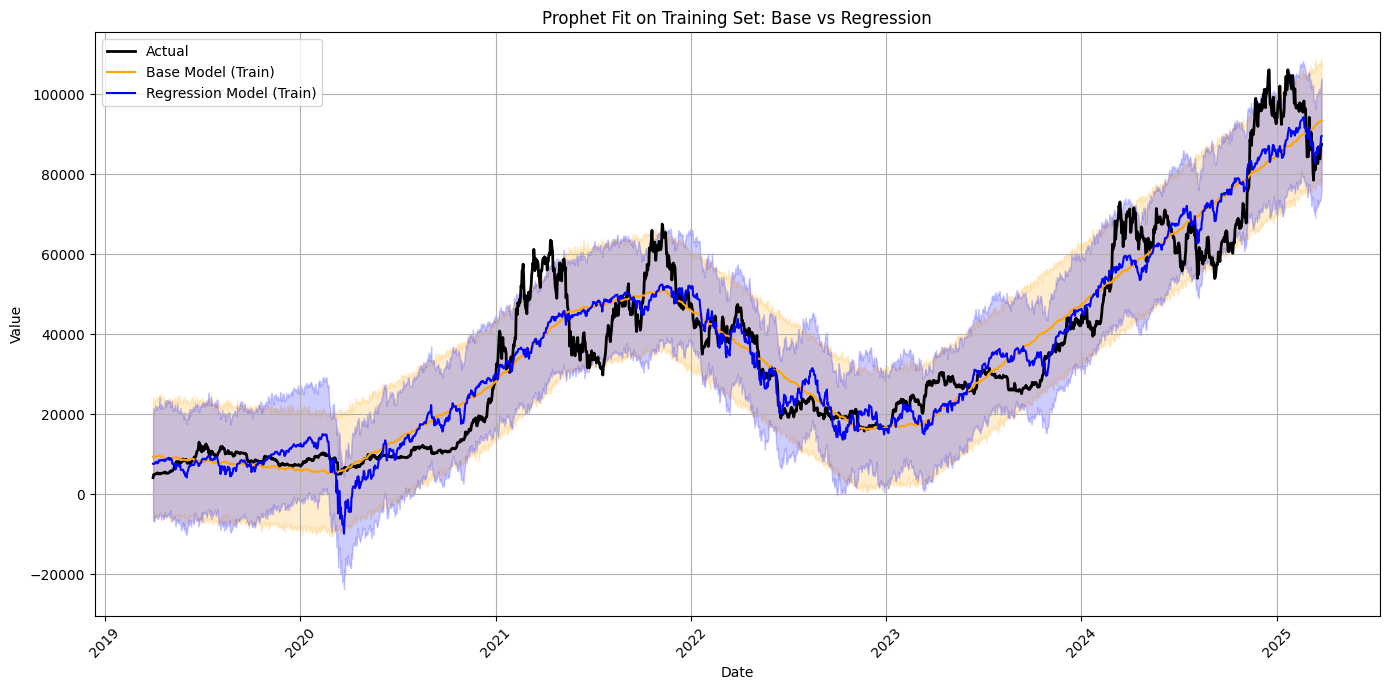

In [33]:

# ========== 1. data ==========
merged_df['ds'] = pd.to_datetime(merged_df['Date'])
df_base = merged_df[['ds', 'y']].copy()
df_r = merged_df[['ds', 'y', 'SP500', 'Gold']].copy()

# ========== 2. Split into training and testing sets ==========
# Use the last 7 rows as the test set
train_base = df_base.iloc[:-7].copy()
test_base = df_base.iloc[-7:].copy()

train_r = df_r.iloc[:-7].copy()
test_r = df_r.iloc[-7:].copy()
# ========== 2. changepoints ==========
changepoints=[
        '2020-03-12', '2020-12-16', '2021-05-19',
        '2021-11-10', '2022-05-09', '2022-11-11',
        '2023-03-13', '2024-12-05'
    ]

# ========== 3. Base Model ==========
m_base = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoints=changepoints,
    interval_width=0.95
).add_seasonality(name='monthly', period=30.5, fourier_order=5)
m_base.fit(train_base)
forecast_base_train = m_base.predict(train_base[['ds']])
train_base['yhat'] = forecast_base_train['yhat']
train_base['yhat_lower'] = forecast_base_train['yhat_lower']
train_base['yhat_upper'] = forecast_base_train['yhat_upper']
evaluate_performance(train_base['y'], train_base['yhat'], model_name="Base Model (Train)")

# ========== 4. Regression Model ==========
m_r = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoints=changepoints,
    interval_width=0.95
).add_seasonality(name='monthly', period=30.5, fourier_order=5)
m_r.add_regressor('SP500')
m_r.add_regressor('Gold')
m_r.fit(train_r)
forecast_r_train = m_r.predict(train_r[['ds', 'SP500', 'Gold']])
train_r['yhat'] = forecast_r_train['yhat']
train_r['yhat_lower'] = forecast_r_train['yhat_lower']
train_r['yhat_upper'] = forecast_r_train['yhat_upper']
evaluate_performance(train_r['y'], train_r['yhat'], model_name="Regression Model (Train)")

# ========== 5. Plot (Train) ==========
plt.figure(figsize=(14, 7))
plt.plot(train_base['ds'], train_base['y'], label='Actual', color='black', linewidth=2)

# Base Model
plt.plot(train_base['ds'], train_base['yhat'], label='Base Model (Train)', color='orange')
plt.fill_between(train_base['ds'], train_base['yhat_lower'], train_base['yhat_upper'], color='orange', alpha=0.2)

# Regression Model
plt.plot(train_r['ds'], train_r['yhat'], label='Regression Model (Train)', color='blue')
plt.fill_between(train_r['ds'], train_r['yhat_lower'], train_r['yhat_upper'], color='blue', alpha=0.2)

plt.title("Prophet Fit on Training Set: Base vs Regression")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The model with regressors provides some benefit, especially in reducing large errors (MSPE), but does not consistently improve performance across all metrics. The improvement is only partially significant (MSPE > 5%).


=== Test Set Evaluation ===
=== Base Model Performance ===
MSPE: 86863810.3114
MAE:  9093.2342
MAPE: 0.1083
PM:   23.8537
----------------------------------------
=== Regression Model Performance ===
MSPE: 4018325.2538
MAE:  1693.1367
MAPE: 0.0203
PM:   1.1035
----------------------------------------


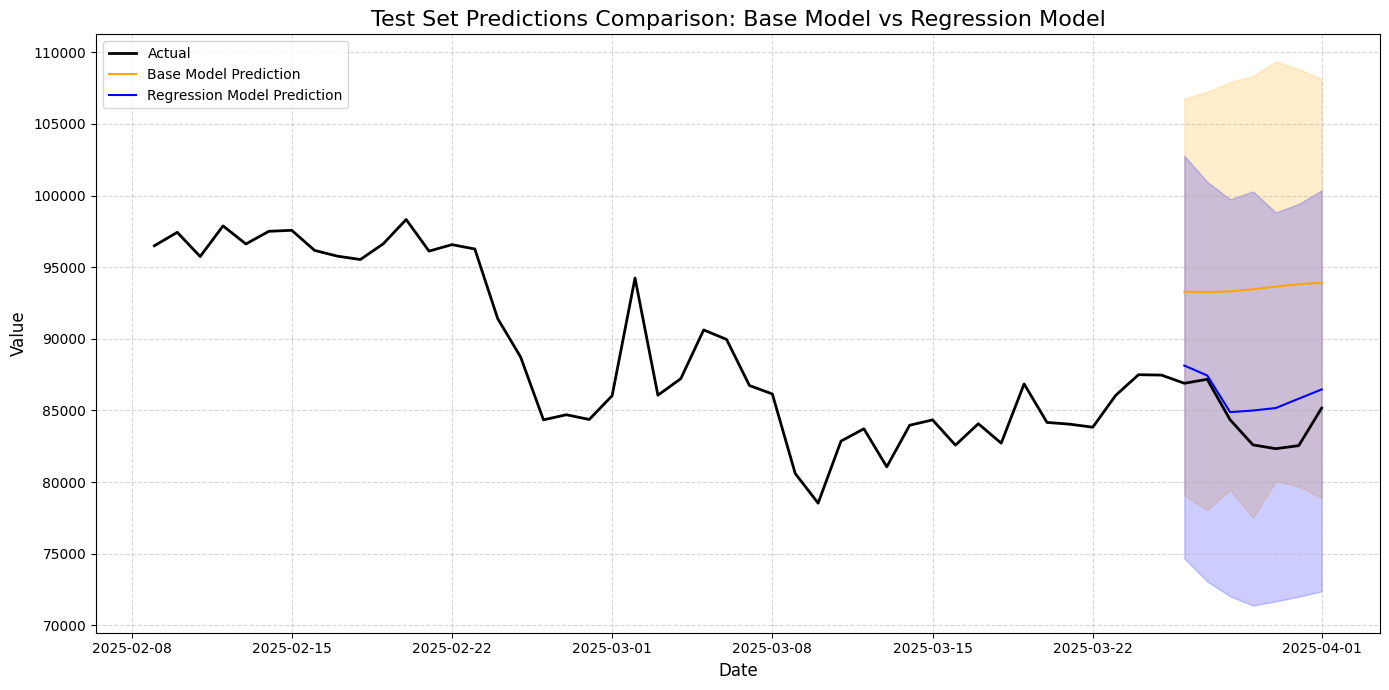

In [34]:

# ========== Step 1. Extend actual data ==========
# Add 45-day historical window before test set for better context
actual_extended = pd.concat([train_base.tail(45), test_base], ignore_index=True)

# ========== Step 2. Make predictions on test set ==========
# Prepare a list to store test predictions from each model
test_predictions = []

# List of trained models and their names
models = [
    ("Base Model", m_base, test_base[['ds']]),
    ("Regression Model", m_r, test_r[['ds', 'SP500', 'Gold']])
]

# Loop through each model and generate test set predictions
for model_name, model, test_X in models:
    # Ensure datetime format for 'ds'
    test_X['ds'] = pd.to_datetime(test_X['ds'])

    # Prophet predict
    forecast = model.predict(test_X)

    # Store predictions
    test_predictions.append((model_name, forecast))

# ========== Step 3. Evaluate model performance ==========
print("\n=== Test Set Evaluation ===")
for (model_name, forecast) in test_predictions:
    # Align forecast and test data for evaluation
    test_y = test_base['y'] if model_name == "Base Model" else test_r['y']
    filtered = pd.concat([test_y.reset_index(drop=True), forecast['yhat']], axis=1).dropna()
    evaluate_performance(filtered.iloc[:, 0], filtered.iloc[:, 1], model_name)

# ========== Step 4. Plot actual data and all model predictions ==========
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(
    actual_extended['ds'],
    actual_extended['y'],
    label='Actual',
    color='black',
    linewidth=2
)

# Define consistent colors for models
colors = ['orange', 'blue']

# Loop through each model's forecast and plot predictions
for idx, (model_name, forecast) in enumerate(test_predictions):
    plt.plot(
        forecast['ds'],
        forecast['yhat'],
        label=f'{model_name} Prediction',
        color=colors[idx],
        linewidth=1.5
    )
    plt.fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        color=colors[idx],
        alpha=0.2
    )

# Add plot labels and title
plt.title('Test Set Predictions Comparison: Base Model vs Regression Model', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()


This suggests that including additional regressors (such as SP500 and Gold) helps the model better capture the underlying data trends, leading to a significant performance improvement.



## Model Prediction

Next, we will compare the GAM and Prophet models. Based on the analysis above, we will consider all helpful components, such as changepoints, seasonality, and trend.

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/v8rqo69k.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/4oobiswl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11124', 'data', 'file=/tmp/tmp5eduz8m0/v8rqo69k.json', 'init=/tmp/tmp5eduz8m0/4oobiswl.json', 'output', 'file=/tmp/tmp5eduz8m0/prophet_modeldsvte40v/prophet_model-20251101201106.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:11:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:11:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
20:11:07 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5eduz8m0/qkat7bwe.json
DE

=== Prophet Performance ===
MSPE: 90273142.7511
MAE:  9279.5943
MAPE: 0.1105
PM:   24.7900
----------------------------------------
=== GAM (Trend Only) Performance ===
MSPE: 230017549.6865
MAE:  15045.7978
MAPE: 0.1788
PM:   63.1653
----------------------------------------
=== GAM (Trend + Seasonality) Performance ===
MSPE: 2175333436.4466
MAE:  42140.0997
MAPE: 0.5004
PM:   597.3698
----------------------------------------


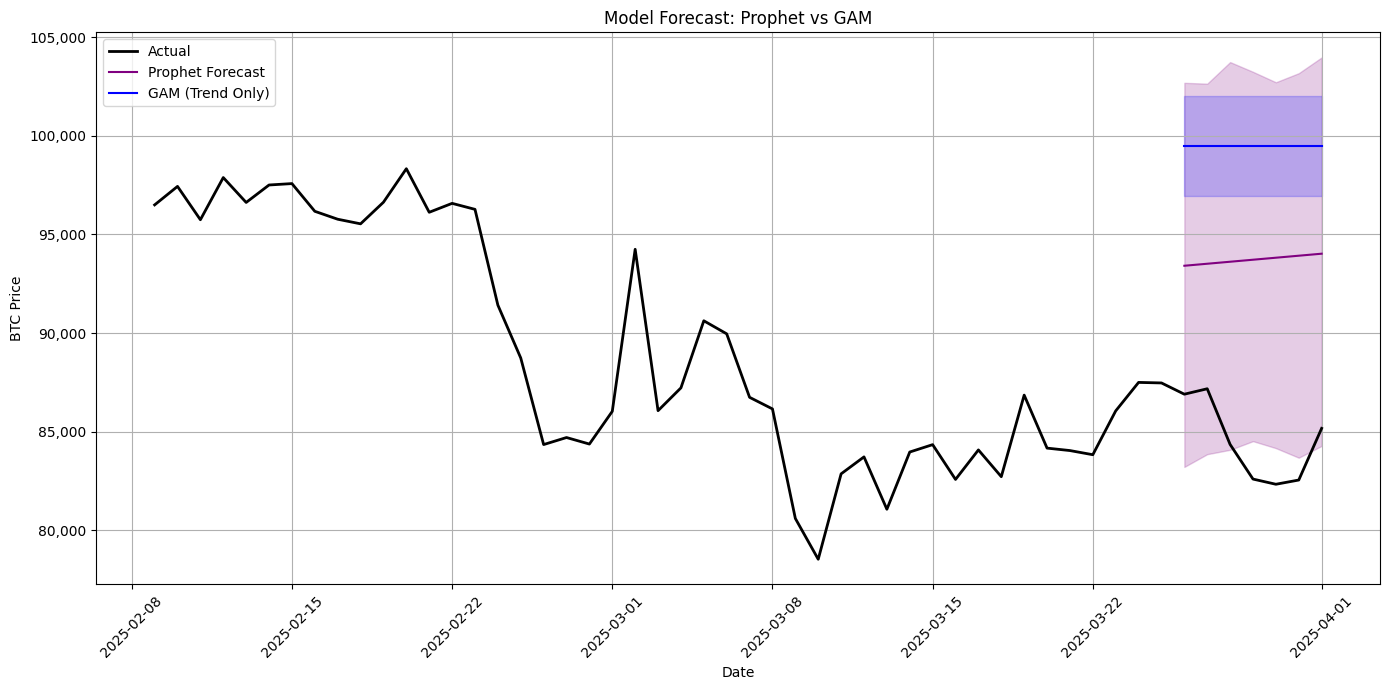

In [35]:

# Filter date range
df = df[(df['ds'] >= '2019-04-01') & (df['ds'] <= '2025-04-01')].sort_values('ds').reset_index(drop=True)

# Split into training and testing sets
train_df = df.iloc[:-7].copy()
test_df = df.iloc[-7:].copy()
train_df['t'] = np.arange(len(train_df))
test_df['t'] = np.arange(len(train_df), len(train_df) + len(test_df))

# ========== Prophet with trend only & custom changepoints ==========
changepoints = ['2020-03-12', '2020-12-16', '2021-05-19', '2021-11-10',
                '2022-05-09', '2022-11-11', '2023-03-13', '2024-12-05']

m = Prophet(yearly_seasonality=False, weekly_seasonality=False, changepoints=changepoints)
m.fit(train_df[['ds', 'y']])
forecast = m.predict(test_df[['ds']])
prophet_forecast = forecast['yhat'].values
prophet_lower = forecast['yhat_lower'].values
prophet_upper = forecast['yhat_upper'].values

# ========== GAM (Trend Only) ==========
X_train_trend = train_df[['t']].values
X_test_trend = test_df[['t']].values

# smoother in train
bs_trend = BSplines(X_train_trend, df=[10], degree=[3])
gam_trend_model = GLMGam(train_df['y'], smoother=bs_trend, alpha=0.1).fit()

# pred GAM (Trend Only)
try:
    gam_pred_trend = gam_trend_model.predict(exog=bs_trend.transform(X_test_trend))
except NotImplementedError:
    X_test_trend_clipped = np.clip(X_test_trend, X_train_trend.min(), X_train_trend.max())
    gam_pred_trend = gam_trend_model.predict(exog=bs_trend.transform(X_test_trend_clipped))

# ========== Step 3b: GAM (Trend + Seasonality) ==========
# Define seasonal features using sine and cosine functions
def add_seasonality(t_array, period):
    return np.column_stack([
        np.sin(2 * np.pi * t_array / period),
        np.cos(2 * np.pi * t_array / period)
    ])

# Add weekly and yearly seasonality to training set
weekly = add_seasonality(train_df['t'].values, 7)
yearly = add_seasonality(train_df['t'].values, 365)
X_train_seasonal = np.column_stack([train_df['t'].values[:, None], weekly, yearly])

# Create a spline basis for the trend component (on the 't' column only)
bs_seasonal = BSplines(X_train_seasonal[:, 0:1], df=[10], degree=[3])

# Fit the GAM model with spline smoother (trend) and linear seasonal components
gam_season_model = GLMGam(
    train_df['y'],
    smoother=bs_seasonal,                  # spline for trend
    exog=X_train_seasonal[:, 1:],          # linear features: weekly/yearly seasonality
    alpha=0.1
).fit()

# Add weekly and yearly seasonality to test set
weekly_test = add_seasonality(test_df['t'].values, 7)
yearly_test = add_seasonality(test_df['t'].values, 365)
X_test_seasonal = np.column_stack([test_df['t'].values[:, None], weekly_test, yearly_test])

# Clip the test time values to the range seen in training to avoid extrapolation errors
X_test_t_clipped = np.clip(
    X_test_seasonal[:, 0:1],
    X_train_seasonal[:, 0:1].min(),
    X_train_seasonal[:, 0:1].max()
)

# Transform the test trend feature using the training spline basis,
# and concatenate with the seasonal features (sin/cos)
gam_pred_season = gam_season_model.predict(
    exog=np.column_stack([
        bs_seasonal.transform(X_test_t_clipped),  # spline-transformed trend
        X_test_seasonal[:, 1:]                    # raw sin/cos seasonal terms
    ])
)


# ========== Step 4: Define evaluation metrics ==========
evaluate_performance(test_df['y'], prophet_forecast, model_name="Prophet")
evaluate_performance(test_df['y'], gam_pred_trend, model_name="GAM (Trend Only)")
evaluate_performance(test_df['y'], gam_pred_season, model_name="GAM (Trend + Seasonality)")

# ========== Step 5: Compute confidence intervals ==========
# For Prophet: Already extracted from forecast

# For GAM (Trend Only)
try:
    trend_ci = gam_trend_model.get_prediction(exog=bs_trend.transform(X_test_trend)).summary_frame()
except NotImplementedError:
    X_test_trend_clipped = np.clip(X_test_trend, X_train_trend.min(), X_train_trend.max())
    trend_ci = gam_trend_model.get_prediction(exog=bs_trend.transform(X_test_trend_clipped)).summary_frame()

gam_trend_lower = trend_ci['mean_ci_lower']
gam_trend_upper = trend_ci['mean_ci_upper']


# For GAM  Trend + Seasonality)
X_test_col0_clipped = np.clip(X_test_seasonal[:, 0:1], X_train_seasonal[:, 0:1].min(), X_train_seasonal[:, 0:1].max())
gam_season_ci = gam_season_model.get_prediction(exog=np.column_stack([bs_seasonal.transform(X_test_col0_clipped), X_test_seasonal[:, 1:]])).summary_frame()

gam_season_lower = gam_season_ci['mean_ci_lower']
gam_season_upper = gam_season_ci['mean_ci_upper']

# ========== Step 6: Plot predictions and confidence intervals ==========
actual_extended = pd.concat([train_df.tail(45), test_df], ignore_index=True)

plt.figure(figsize=(14, 7))
plt.plot(actual_extended['ds'], actual_extended['y'], label='Actual', color='black', linewidth=2)

# Prophet forecast with CI
plt.plot(test_df['ds'], prophet_forecast, label='Prophet Forecast', color='purple')
plt.fill_between(test_df['ds'], prophet_lower, prophet_upper, color='purple', alpha=0.2)

# GAM (Trend Only) with CI
plt.plot(test_df['ds'], gam_pred_trend, label='GAM (Trend Only)', color='blue')
plt.fill_between(test_df['ds'], gam_trend_lower, gam_trend_upper, color='blue', alpha=0.2)

# GAM (Trend + Seasonality) with CI
#plt.plot(test_df['ds'], gam_pred_season, label='GAM (Trend + Seasonality)', color='green')
#plt.fill_between(test_df['ds'], gam_season_lower, gam_season_upper, color='green', alpha=0.2)

plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.title("Model Forecast: Prophet vs GAM")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()




Based on the evaluation results, the Prophet model significantly outperforms both GAM models, achieving the higest scores. Adding seasonality to the GAM model results in a poorer, unstable prediction. Thus GAM, while non-parametric in nature, lags Prophet in both accuracy and stability of the prediction.